In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_1_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_1_patch_full = xr.open_dataset(emulator_1_path, consolidated=True) 

emulator_2_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-04-06-eval:samudra_llc:Agulhas,from-4-4-26-RESUME/predictions_4d.zarr'
emulator_2_patch_full = xr.open_dataset(emulator_2_path, consolidated=True) 

In [3]:
extent = 48
llc_patch = llc_patch_full.isel(time=slice(9216, 9216+extent))
emulator_1_patch = emulator_1_patch_full.isel(time=slice(0, extent))
emulator_2_patch = emulator_2_patch_full.isel(time=slice(0, extent))

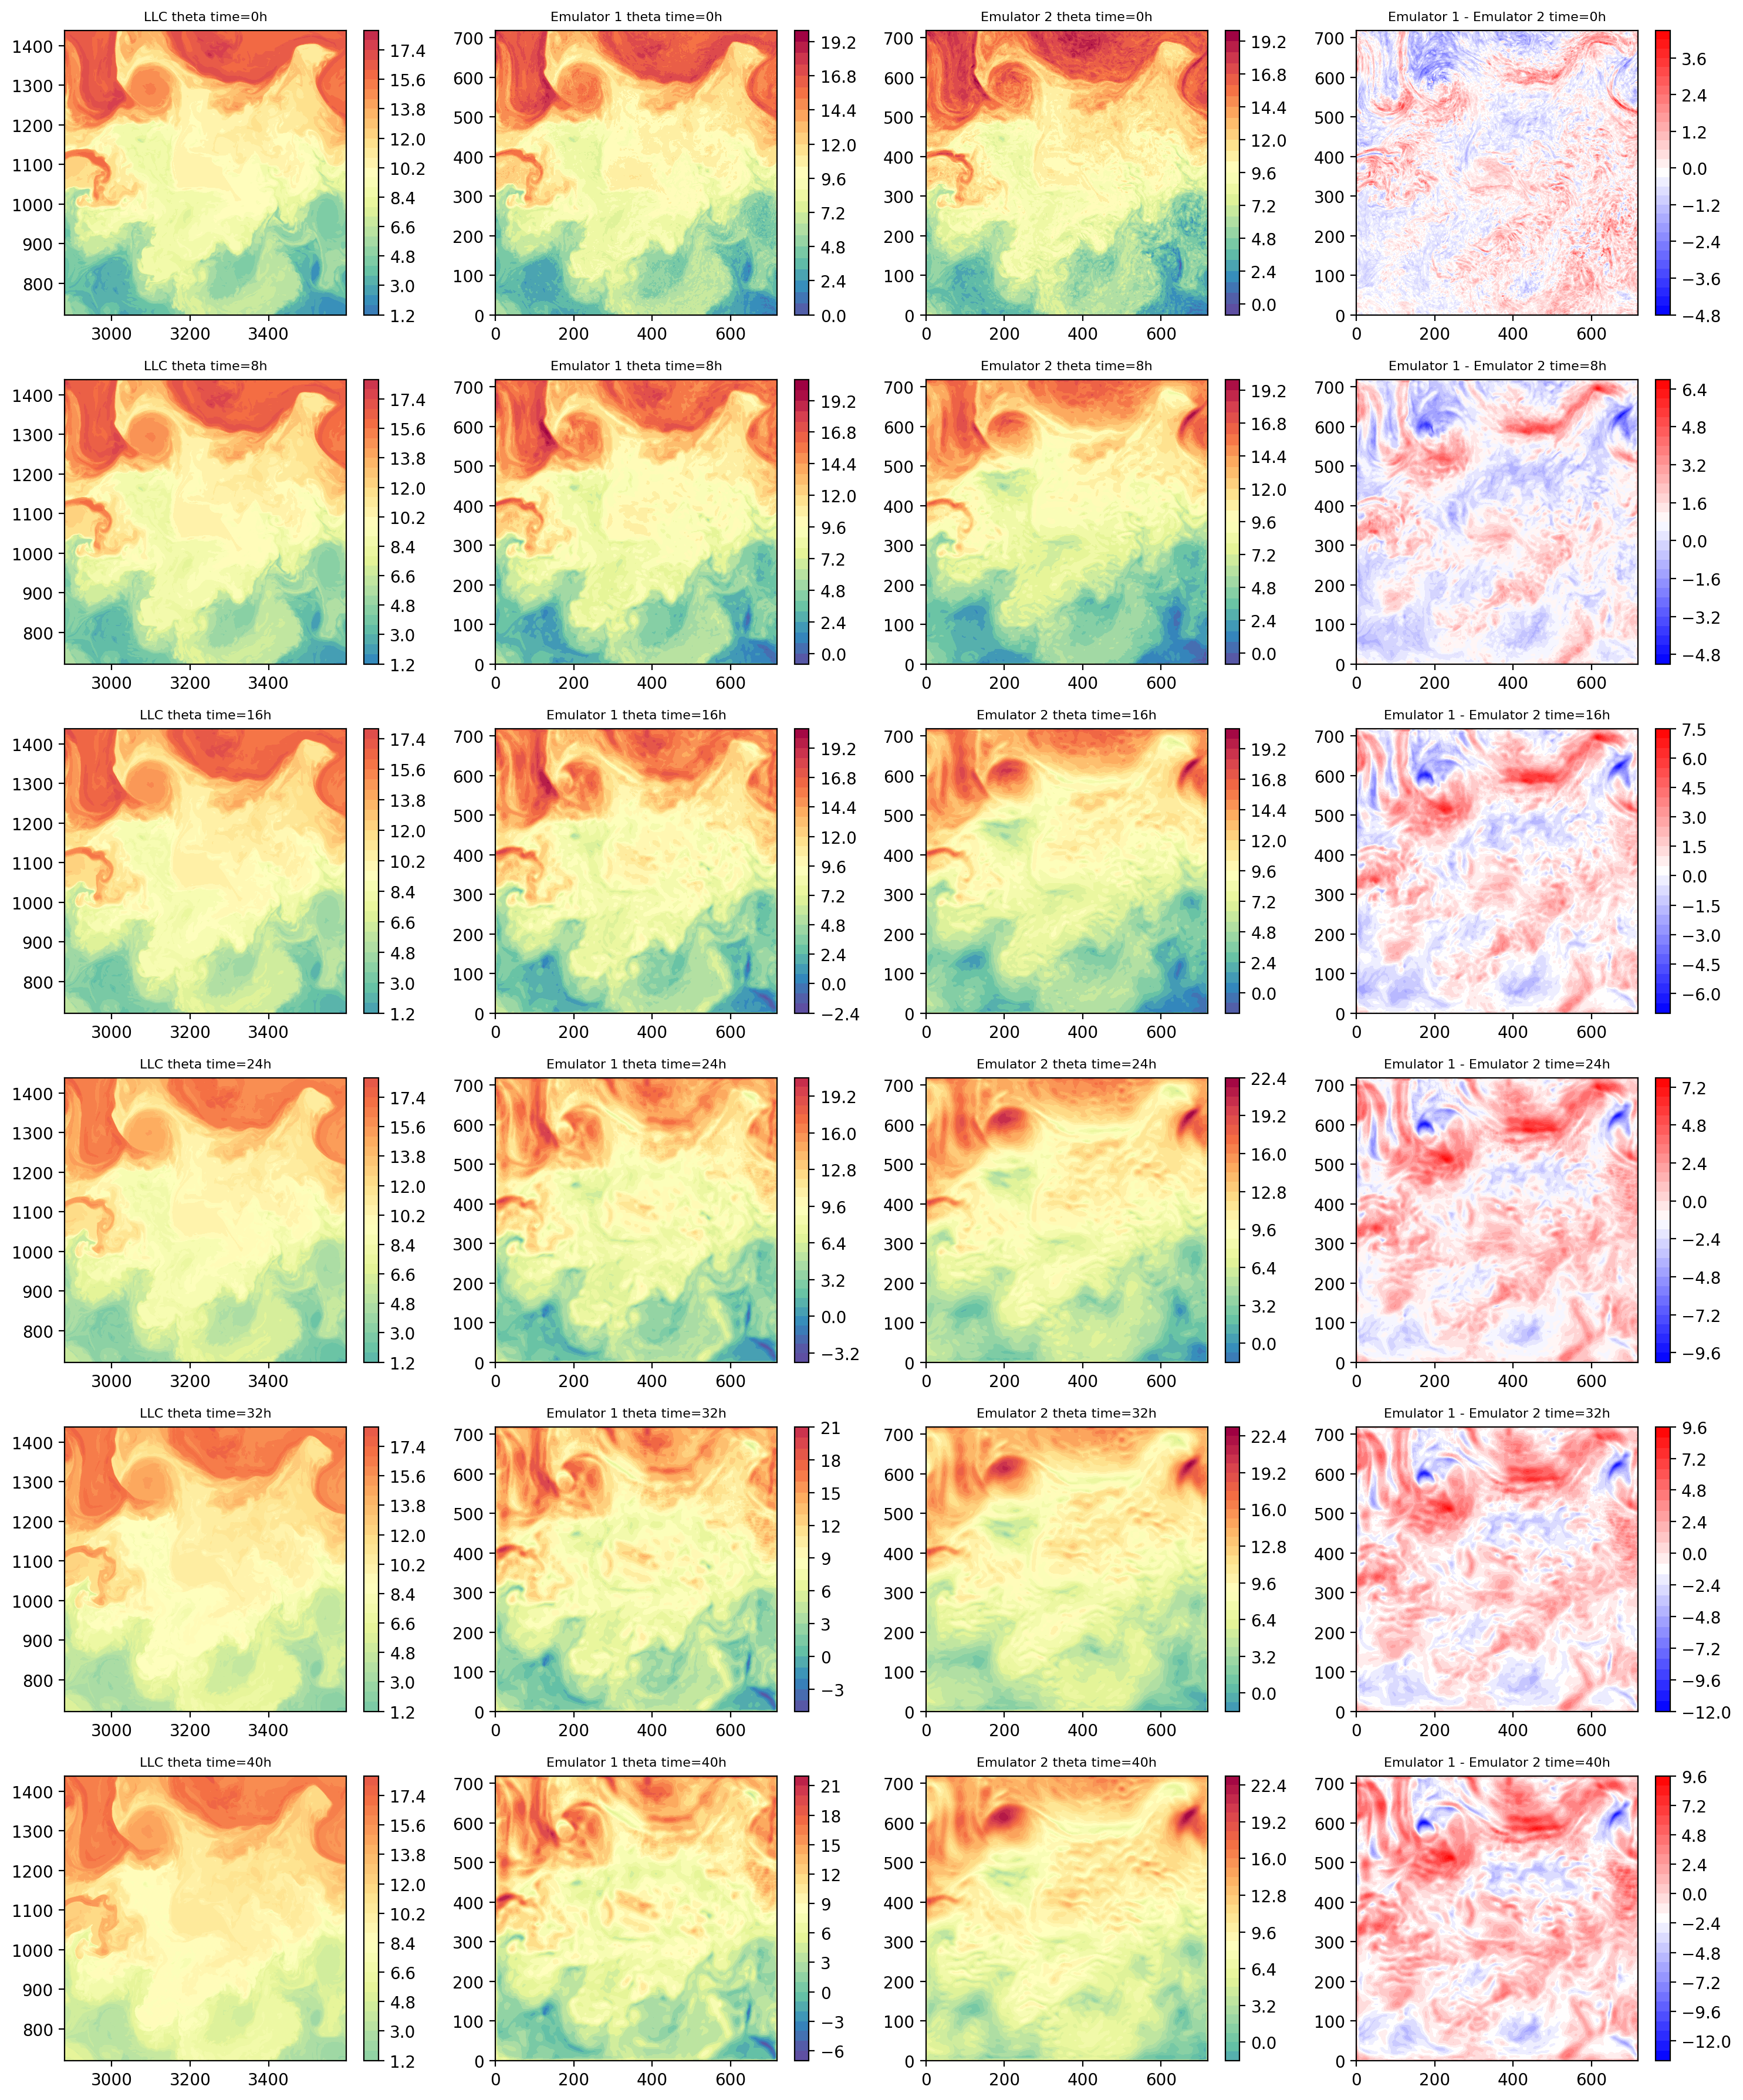

In [4]:
n_times = min(48, len(llc_patch['time']))
time_step = 8  # every 4 hours
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).Theta
    emulator_1_vis = emulator_1_patch.isel(time=t, k=0).Theta
    emulator_2_vis = emulator_2_patch.isel(time=t, k=0).Theta
    
    # Get shared vmin/vmax for first three columns
    vmin = np.min([llc_vis.values.min(), emulator_1_vis.values.min(), emulator_2_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_1_vis.values.max(), emulator_2_vis.values.max()])
    
    ax1, ax2, ax3, ax4 = axes[row, 0], axes[row, 1], axes[row, 2], axes[row, 3]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax1.set_title(f'LLC theta time={t}h', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_1_vis.coords.get('i', np.arange(emulator_1_vis.shape[-1])), \
        emulator_1_vis.coords.get('j', np.arange(emulator_1_vis.shape[-2])), emulator_1_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax2.set_title(f'Emulator 1 theta time={t}h', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    cf3 = ax3.contourf(emulator_2_vis.coords.get('i', np.arange(emulator_2_vis.shape[-1])), \
        emulator_2_vis.coords.get('j', np.arange(emulator_2_vis.shape[-2])), emulator_2_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax3.set_title(f'Emulator 2 theta time={t}h', fontsize=8)
    plt.colorbar(cf3, ax=ax3)
    
    diff = emulator_1_vis.values - emulator_2_vis.values
    cf4 = ax4.contourf(emulator_2_vis.coords.get('i', np.arange(emulator_2_vis.shape[-1])), \
        emulator_2_vis.coords.get('j', np.arange(emulator_2_vis.shape[-2])), diff, \
            cmap="bwr", levels = 30)
    ax4.set_title(f'Emulator 1 - Emulator 2 time={t}h', fontsize=8)
    plt.colorbar(cf4, ax=ax4)

plt.tight_layout()
plt.show()

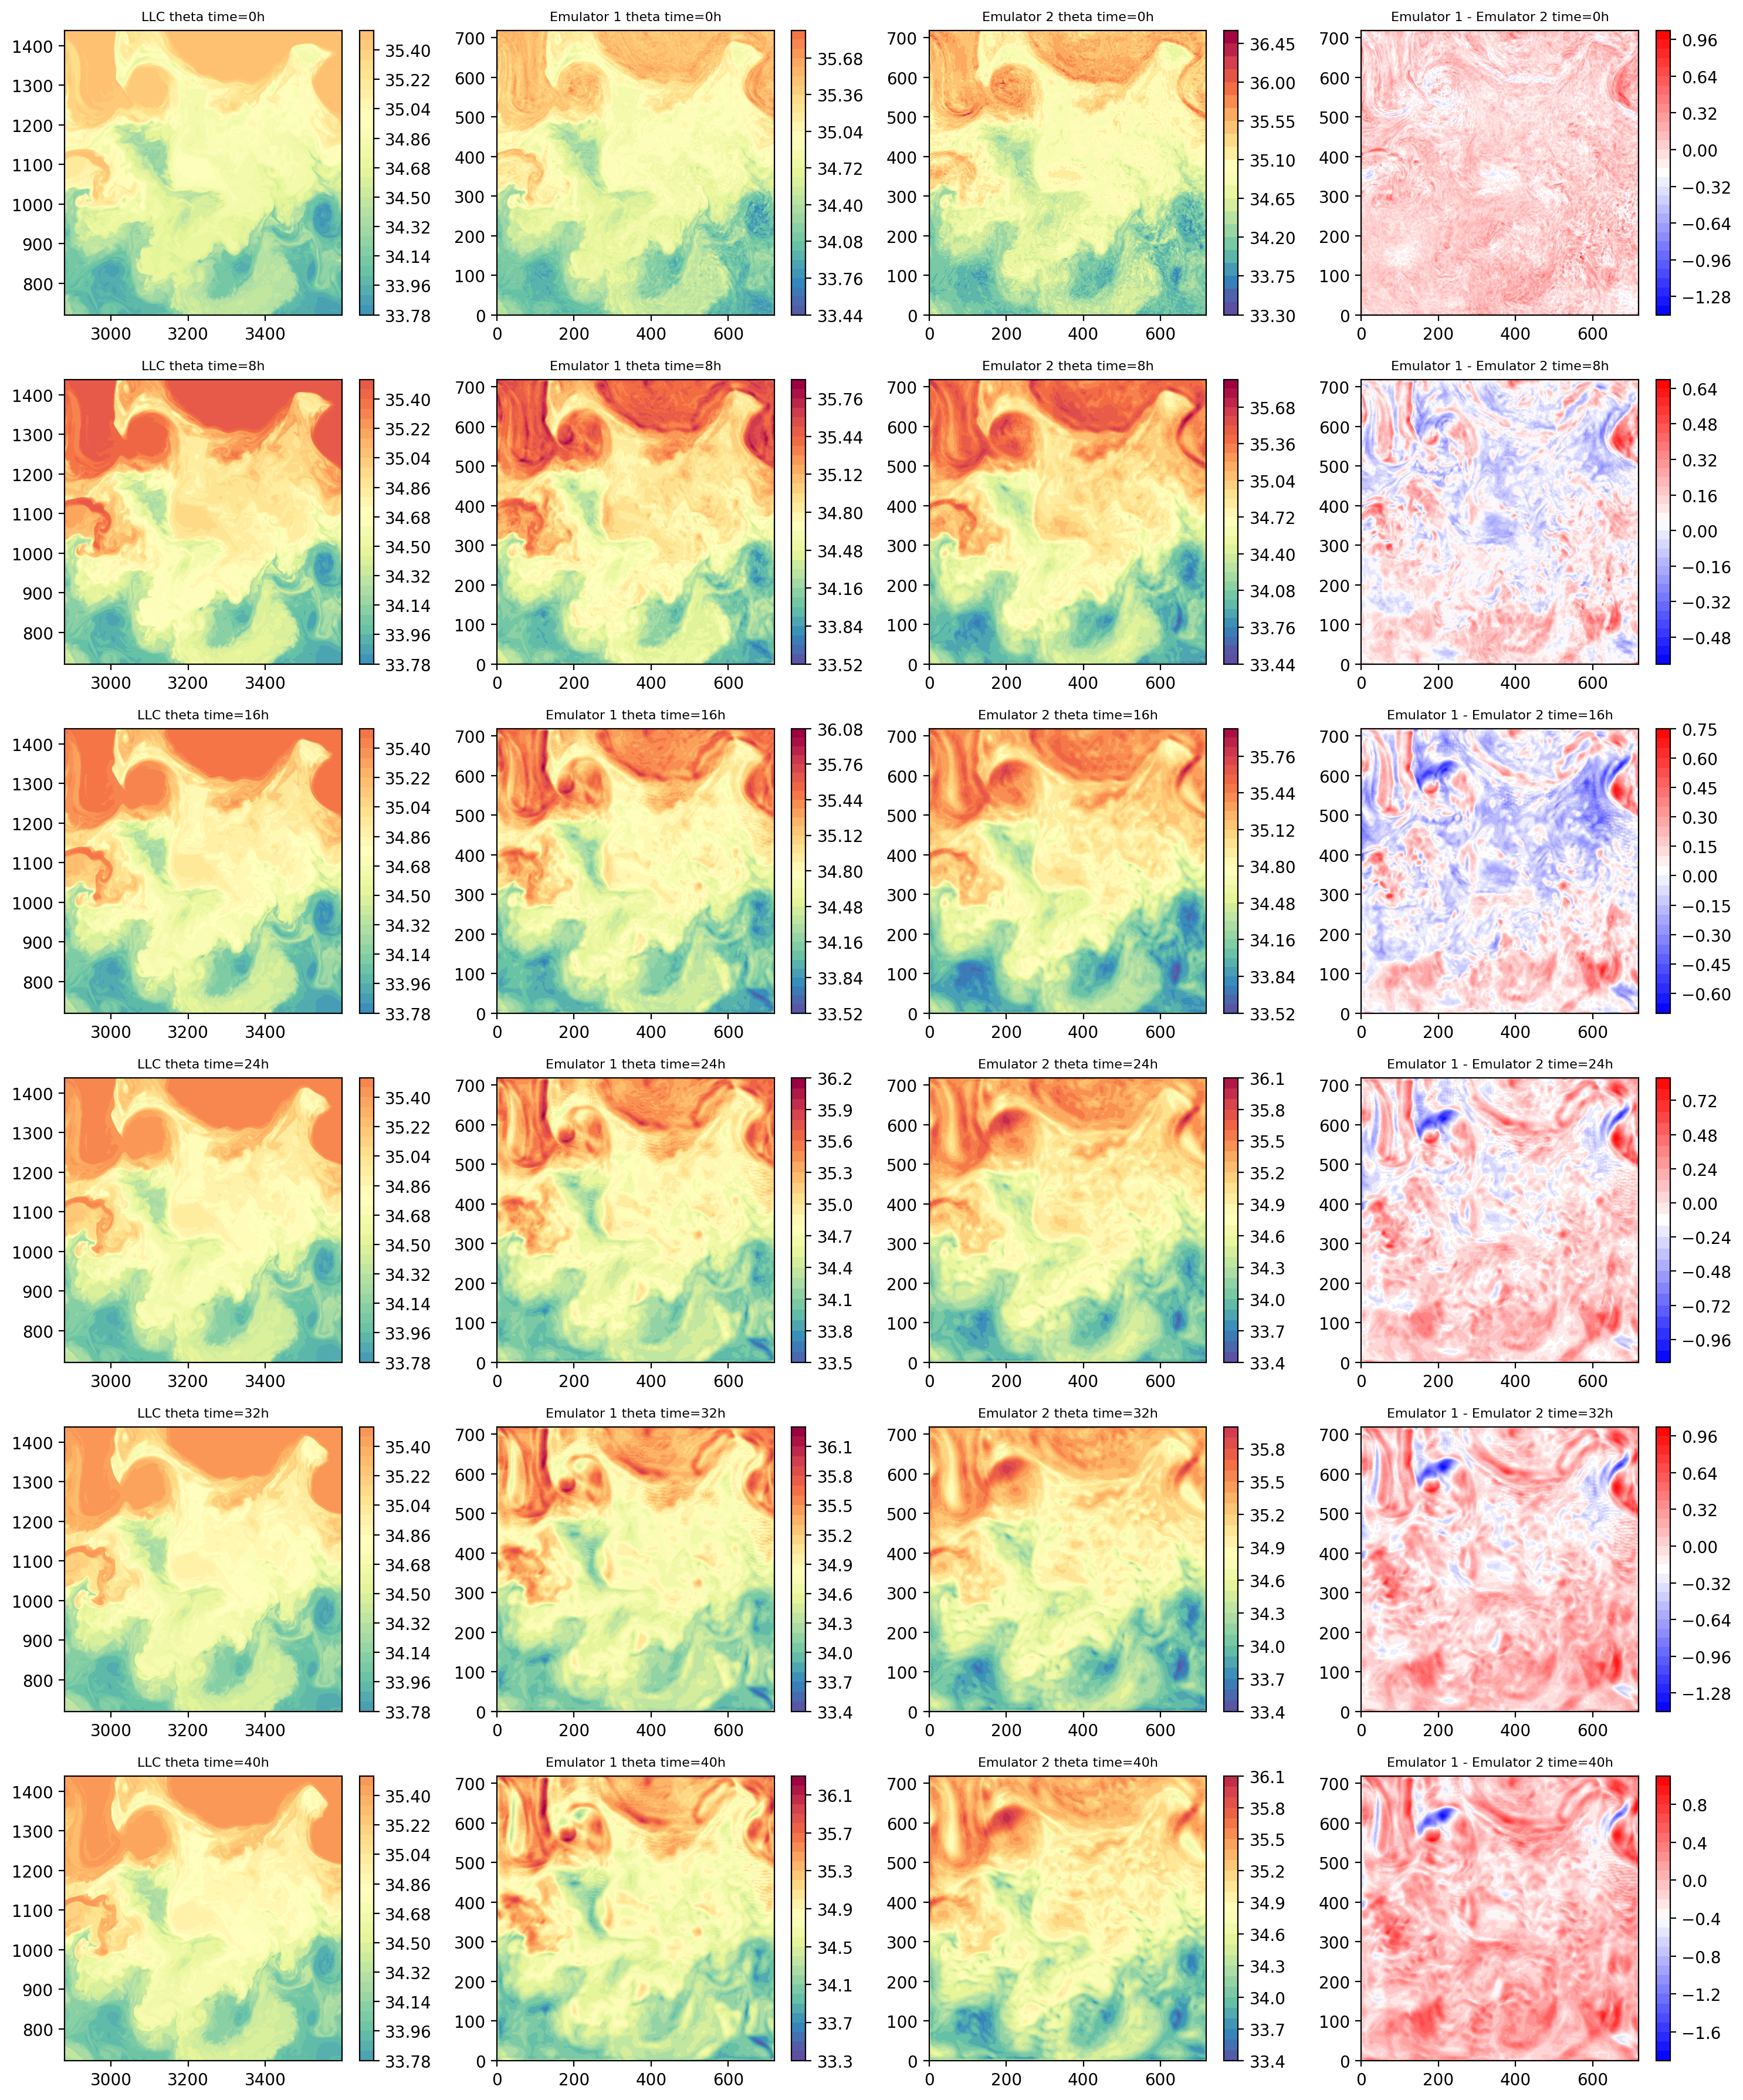

In [5]:
n_times = min(48, len(llc_patch['time']))
time_step = 8  # every 4 hours
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).Salt
    emulator_1_vis = emulator_1_patch.isel(time=t, k=0).Salt
    emulator_2_vis = emulator_2_patch.isel(time=t, k=0).Salt
    
    # Get shared vmin/vmax for first three columns
    vmin = np.min([llc_vis.values.min(), emulator_1_vis.values.min(), emulator_2_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_1_vis.values.max(), emulator_2_vis.values.max()])
    
    ax1, ax2, ax3, ax4 = axes[row, 0], axes[row, 1], axes[row, 2], axes[row, 3]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax1.set_title(f'LLC theta time={t}h', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_1_vis.coords.get('i', np.arange(emulator_1_vis.shape[-1])), \
        emulator_1_vis.coords.get('j', np.arange(emulator_1_vis.shape[-2])), emulator_1_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax2.set_title(f'Emulator 1 theta time={t}h', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    cf3 = ax3.contourf(emulator_2_vis.coords.get('i', np.arange(emulator_2_vis.shape[-1])), \
        emulator_2_vis.coords.get('j', np.arange(emulator_2_vis.shape[-2])), emulator_2_vis, \
            cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
    ax3.set_title(f'Emulator 2 theta time={t}h', fontsize=8)
    plt.colorbar(cf3, ax=ax3)
    
    diff = emulator_1_vis.values - emulator_2_vis.values
    cf4 = ax4.contourf(emulator_2_vis.coords.get('i', np.arange(emulator_2_vis.shape[-1])), \
        emulator_2_vis.coords.get('j', np.arange(emulator_2_vis.shape[-2])), diff, \
            cmap="bwr", levels = 30)
    ax4.set_title(f'Emulator 1 - Emulator 2 time={t}h', fontsize=8)
    plt.colorbar(cf4, ax=ax4)

plt.tight_layout()
plt.show()